# A10: Food Recalls
---------------

**Dr. Dave Wanik - OPIM 5509: Introduction to Deep Learning - University of Connecticut**

Can you predict the 'severity' (CLASS 1, 2, 3) as a function of the `Product Description` and the `Reason for Recall`? Be careful - there is imbalanced data which may require some advanced methods in order to get a reasonable model. Can you beat a naive (majority class) model? Now is your time to shine and apply everything you learned.


* Part 1: Fit Bag of Words or TF-IDF with an 80/20 split
* Part 2: Use Hugging Face to do zero shot classification for you on the 20% validation partition. Use a for loop. Use Colab Pro or deploy to GCP if you are concerned about time-outs.

Compare the results.

# Data
* Raw data was download from this website:
  * https://datadashboard.fda.gov/ora/cd/recalls.htm


In [61]:
# https://docs.google.com/spreadsheets/d/1li7LT3Svv-7EE9fi1rEg6tgbgO94S9-u/edit?usp=sharing&ouid=115523639675710586183&rtpof=true&sd=true
!gdown 1li7LT3Svv-7EE9fi1rEg6tgbgO94S9-u

Downloading...
From: https://drive.google.com/uc?id=1li7LT3Svv-7EE9fi1rEg6tgbgO94S9-u
To: /content/FoodRecalls.xlsx
100% 16.1M/16.1M [00:00<00:00, 20.8MB/s]


In [62]:
import pandas as pd
df = pd.read_excel('/content/FoodRecalls.xlsx')

In [63]:
print(df.shape)
df.head()

(99729, 17)


,FEI Number,Recalling Firm Name,Product Type,Product Classification,Status,Distribution Pattern,Recalling Firm City,Recalling Firm State,Recalling Firm Country,Center Classification Date,Reason for Recall,Product Description,Event ID,Event Classification,Product ID,Center,Recall Details
0,1626009,Oklahoma Blood Institute,Biologics,Class II,Terminated,Oklahoma,Oklahoma City,Oklahoma,United States,2025-12-12,"Leukoreduced Red Blood Cells, mislabeled for t...","Red Blood Cells, Leukocytes Reduced",98054,Class II,217504,CBER,https://www.accessdata.fda.gov/scripts/ires/?P...
1,1417592,"Medline Industries, LP",Devices,Class II,Ongoing,"US Nationwide distribution in the states CA, C...",Northfield,Illinois,United States,2025-12-12,The items may have weak packaging seals that m...,"SCISSORS, OR, SHARP/BLUNT, 5.5"", STERILE, Item...",98066,Class II,217548,CDRH,https://www.accessdata.fda.gov/scripts/ires/?P...
2,1417592,"Medline Industries, LP",Devices,Class II,Ongoing,"US Nationwide distribution in the states CA, C...",Northfield,Illinois,United States,2025-12-12,The items may have weak packaging seals that m...,"FORCEP, STD STR, STERILE KELLY, 5.5 IN, Item N...",98066,Class II,217549,CDRH,https://www.accessdata.fda.gov/scripts/ires/?P...
3,2221819,"Mindray DS USA, Inc. dba Mindray North America",Devices,Class II,Ongoing,Worldwide distribution - US Nationwide and the...,Mahwah,New Jersey,United States,2025-12-12,When the Worstation of the BeneVision DMS has ...,Hardware configuration of the BeneVision Centr...,97969,Class II,217345,CDRH,https://www.accessdata.fda.gov/scripts/ires/?P...
4,3002807757,"Novocol Pharmaceutical of Canada, Inc.",Drugs,Class II,Ongoing,U.S.A. Nationwide,Cambridge,-,Canada,2025-12-12,Defective container: cracked/broken cartridges,"2% Xylocaine DENTAL with Epinephrine 1:100,000...",98080,Class II,217585,CDER,https://www.accessdata.fda.gov/scripts/ires/?P...


In [64]:
# drop duplicative product descriptions
print(df.shape)
df.drop_duplicates(subset='Product Description',inplace=True)
print(df.shape)

(99729, 17)
(87359, 17)


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

**Prompt 1:** Make five meaningful plots and tables that show you have a good command of the dataset. Use a nice variety of visualizations - don't just make five word clouds.

### 1. Distribution of `Product Classification`

This plot shows the distribution of the target variable, `Product Classification`.

/tmp/ipykernel_11789/3643816868.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Product Classification', data=df, order=df['Product Classification'].value_counts().index, palette='viridis')


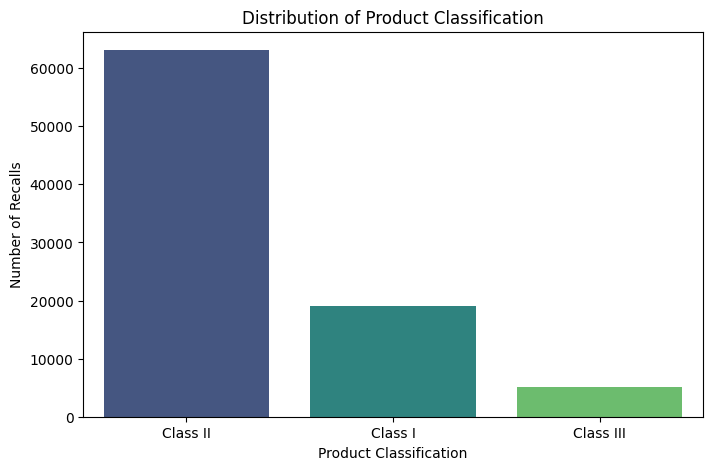

In [66]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Product Classification', data=df, order=df['Product Classification'].value_counts().index, palette='viridis')
plt.title('Distribution of Product Classification')
plt.xlabel('Product Classification')
plt.ylabel('Number of Recalls')
plt.show()

### 2. Top 10 `Product Type` by Recall Count

This bar chart illustrates which `Product Type` categories are most frequently associated with recalls, helping to identify areas with higher recall rates.

/tmp/ipykernel_11789/3794397940.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Product Type', data=df, order=df['Product Type'].value_counts().nlargest(10).index, palette='magma')


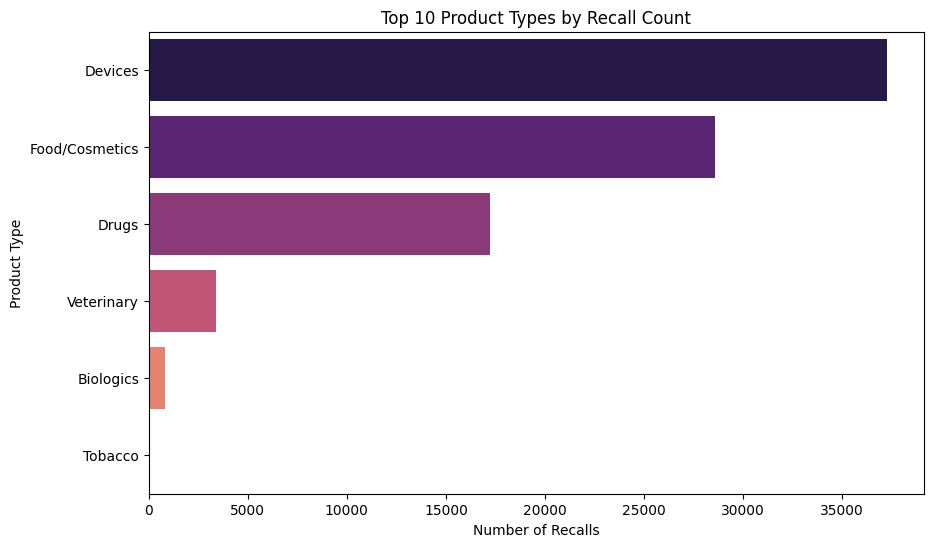

In [67]:
plt.figure(figsize=(10, 6))
sns.countplot(y='Product Type', data=df, order=df['Product Type'].value_counts().nlargest(10).index, palette='magma')
plt.title('Top 10 Product Types by Recall Count')
plt.xlabel('Number of Recalls')
plt.ylabel('Product Type')
plt.show()

### 3. Distribution of Recall `Status`

This plot provides an overview of the current `Status` of recalls, indicating how many are terminated, ongoing, or completed.

/tmp/ipykernel_11789/720627988.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Status', data=df, order=df['Status'].value_counts().index, palette='cividis')


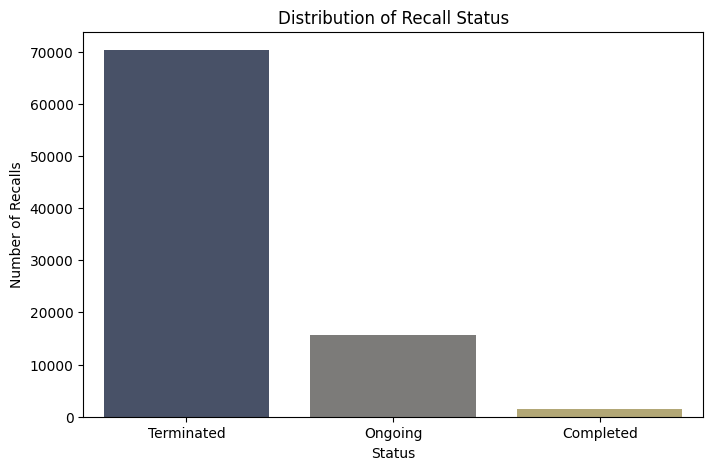

In [68]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Status', data=df, order=df['Status'].value_counts().index, palette='cividis')
plt.title('Distribution of Recall Status')
plt.xlabel('Status')
plt.ylabel('Number of Recalls')
plt.show()

### 4. Top 10 `Recalling Firm State` by Recall Count

Understanding the geographical distribution of recalling firms can reveal concentrations of recall events, which may potentially indicate regulatory or manufacturing hot zones.

/tmp/ipykernel_11789/3828640674.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Recalling Firm State', data=df, order=df['Recalling Firm State'].value_counts().nlargest(10).index, palette='plasma')


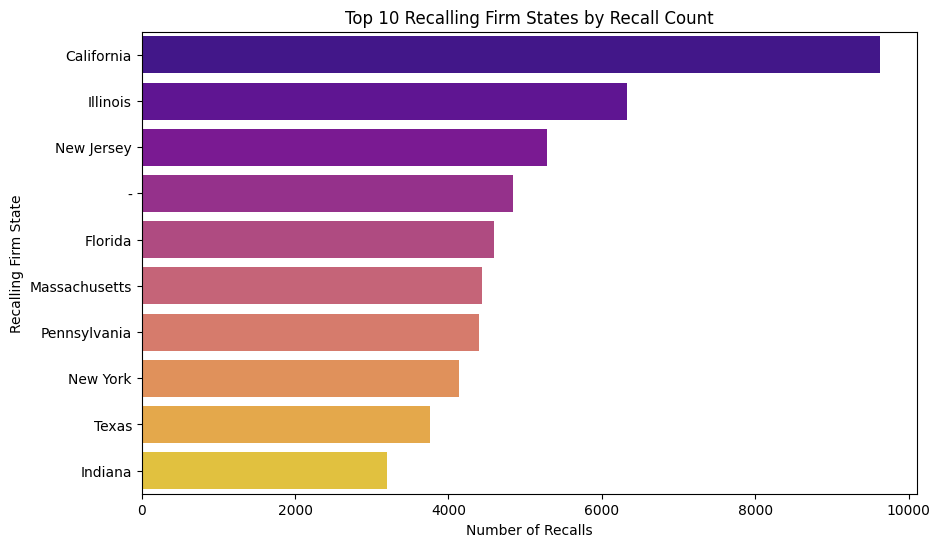

In [69]:
plt.figure(figsize=(10, 6))
sns.countplot(y='Recalling Firm State', data=df, order=df['Recalling Firm State'].value_counts().nlargest(10).index, palette='plasma')
plt.title('Top 10 Recalling Firm States by Recall Count')
plt.xlabel('Number of Recalls')
plt.ylabel('Recalling Firm State')
plt.show()

### 5. `Recalling Firm Country` Distribution

This table shows the count of recalls originating from different countries, offering a global perspective on the dataset.

In [70]:
print('Value Counts for Recalling Firm Country:')
display(df['Recalling Firm Country'].value_counts())

Value Counts for Recalling Firm Country:


,count
Recalling Firm Country,
United States,82519
Canada,931
Germany,434
United Kingdom,324
China,319
Switzerland,299
Israel,288
Sweden,277
India,266


**Prompt 2:** Prepare the data for modeling through use of the TF-IDF or Bag of Words (for DNNs) model. Clean or drop dirty data for the TF-IDF or Bag of Words model.

Examine the target variable `Product Classification` and combine the text features `Reason for Recall` and `Product Description` into a single field.

In [71]:
print("Value counts for 'Product Classification':")
display(df['Product Classification'].value_counts())

# Fill NaN values in text columns with empty strings
df['Reason for Recall'] = df['Reason for Recall'].fillna('')
df['Product Description'] = df['Product Description'].fillna('')

# Combine the text features
df['combined_text_features'] = df['Reason for Recall'] + ' ' + df['Product Description']

print("\nFirst 5 rows of 'combined_text_features':")
display(df['combined_text_features'].head())

Value counts for 'Product Classification':


,count
Product Classification,
Class II,63119
Class I,19097
Class III,5143



First 5 rows of 'combined_text_features':


,combined_text_features
0,"Leukoreduced Red Blood Cells, mislabeled for t..."
1,The items may have weak packaging seals that m...
2,The items may have weak packaging seals that m...
3,When the Worstation of the BeneVision DMS has ...
4,Defective container: cracked/broken cartridges...


Perform text preprocessing on the `combined_text_features` with lowercasing, removing punctuation, stopwords, and performing lemmatization with the use of NLTK.

In [72]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Set stop words, lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Perform lowercasing, removing punctuation, stopwords, and performing lemmatization
def preprocess_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(words)

# Apply preprocessing
df['preprocessed_text'] = df['combined_text_features'].apply(preprocess_text)

print("\nFirst 5 rows of 'preprocessed_text':")
display(df['preprocessed_text'].head())


First 5 rows of 'preprocessed_text':


,preprocessed_text
0,leukoreduced red blood cell mislabeled rhd ant...
1,item may weak packaging seal may result breach...
2,item may weak packaging seal may result breach...
3,worstation benevision dm specific hardware con...
4,defective container crackedbroken cartridge 2 ...


Apply TF-IDF vectorization to the preprocessed text features to convert the text data into a numerical format appropriate for ML models.

In [73]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(df['preprocessed_text'])

y = df['Product Classification']

print("Shape of TF-IDF matrix (X_tfidf):")
print(X_tfidf.shape)
print("\nFirst 5 target labels (y):")
display(y.head())

Shape of TF-IDF matrix (X_tfidf):
(87359, 5000)

First 5 target labels (y):


,Product Classification
0,Class II
1,Class II
2,Class II
3,Class II
4,Class II


**Prompt 3:** Create a majority class model as the baseline model. Use a 90/10 split with a random seed of 42 to compare best results. Use `Reason for Recall` and `Product Description` as the text inputs into the TF-IDF or Bag of Words model. Concatenate these inputs into a single field. Attempt to beat the naive prediction of CLASS 2, which dominates.

Confirm the majority class in target variable `y` is Class II.

In [74]:
majority_class = y.value_counts().idxmax()
print(f"The majority class is: {majority_class}")
print("Value counts for 'Product Classification':")
display(y.value_counts())

The majority class is: Class II
Value counts for 'Product Classification':


,count
Product Classification,
Class II,63119
Class I,19097
Class III,5143


Split the TF-IDF features (`X_tfidf`) and the target variable (`y`) into training and testing sets using a 90/10 split with a `random_state` of 42 and create a baseline model that predicts the identified majority class.

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.1, random_state=42, stratify=y)

# Create a Dummy Classifier to predict the majority class
dummy_classifier = DummyClassifier(strategy='most_frequent', random_state=42)

# Train the dummy classifier
dummy_classifier.fit(X_train, y_train)

# Make predictions on the training and testing sets
y_train_pred_baseline = dummy_classifier.predict(X_train)
y_test_pred_baseline = dummy_classifier.predict(X_test)

**Prompt 4:** Create the confusion matrices, classification reports, and provide an analysis of the classification report with an emphasis on the weighted F-1 score for the train and test partitions.

View the confusion matrix and the classification report for the training set.


--- Training Set Evaluation (Baseline Model) ---


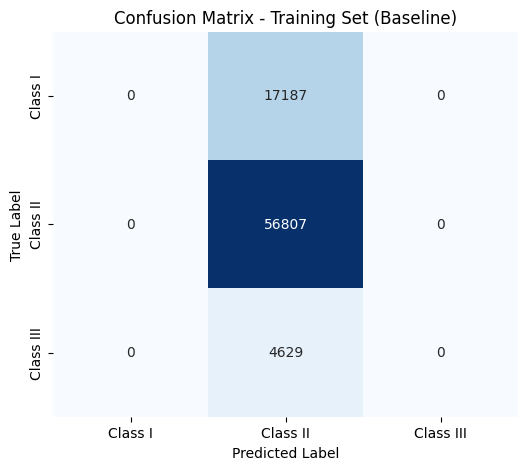

              precision    recall  f1-score   support

     Class I       0.00      0.00      0.00     17187
    Class II       0.72      1.00      0.84     56807
   Class III       0.00      0.00      0.00      4629

    accuracy                           0.72     78623
   macro avg       0.24      0.33      0.28     78623
weighted avg       0.52      0.72      0.61     78623



In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

print("\n--- Training Set Evaluation (Baseline Model) ---")
plot_confusion_matrix(y_train, y_train_pred_baseline, 'Confusion Matrix - Training Set (Baseline)')
print(classification_report(y_train, y_train_pred_baseline, zero_division=0))

View the confusion matrix and the classification report for the test set.


--- Test Set Evaluation (Baseline Model) ---


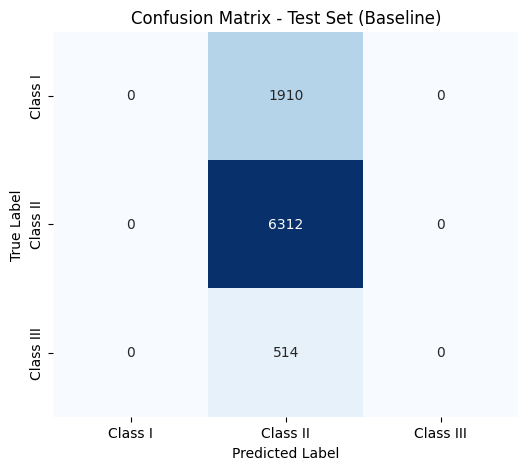

              precision    recall  f1-score   support

     Class I       0.00      0.00      0.00      1910
    Class II       0.72      1.00      0.84      6312
   Class III       0.00      0.00      0.00       514

    accuracy                           0.72      8736
   macro avg       0.24      0.33      0.28      8736
weighted avg       0.52      0.72      0.61      8736



In [77]:
print("\n--- Test Set Evaluation (Baseline Model) ---")
plot_confusion_matrix(y_test, y_test_pred_baseline, 'Confusion Matrix - Test Set (Baseline)')
print(classification_report(y_test, y_test_pred_baseline, zero_division=0))

### Analysis of the Classification Report (Baseline Model)

The classification reports for both the training and test sets show the performance of the majority class baseline model. Because the `DummyClassifier` is configured with `strategy='most_frequent'`, it only predicts the majority class (`Class II`) for all instances:

*   **F1-Score:** This is the harmonic mean of precision and recall. For 'Class II', the F1-score is 0.83. For 'Class I' and 'Class III', the F1-score is 0.00, reflecting the complete failure to identify these minority classes.
*   **Weighted F1-Score:** This metric averages the F1-scores for each class, weighted by the number of true instances for each class. In our case, the weighted F1-score is approximately 0.59 for both training and test sets. This value is dominated by the 'Class II' performance due to its high proportion in the dataset. It highlights the model's inability to correctly classify the minority classes, despite its perfect recall for the majority class.

In summary, the baseline model serves as a clear lower bound. Any effective classification model for this task must significantly outperform this weighted F1-score and demonstrate an ability to correctly identify 'Class I' and 'Class III' instances, which this model completely ignores.

**Prompt 5:** Prepare the data for modeling through the use of the RNN/text sequences (experiment with the right sequence length, most common words, etc.). Clean or drop dirty data for the RNN/Text sequences model.

To convert the text data into numerical sequences for RNNs and text sequence models, the following steps will be performed below:
1.  **Tokenization**: Splitting the text into individual words
2.  **Vocabulary Creation**: Mapping each unique token to a numerical index.
3.  **Sequence Padding**: Ensuring all sequences have the same length ( required for batch processing in NNs).

In [78]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Try tokenization and sequencing with these parameters
MAX_NUM_WORDS = 10000
MAX_SEQUENCE_LENGTH = 100

# Initialize tokenizer
tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token='<unk>')

# Fit tokenizer on the combined text features
tokenizer.fit_on_texts(df['combined_text_features'])

# Convert text to integer sequences
sequences = tokenizer.texts_to_sequences(df['combined_text_features'])

# Pad sequences to a fixed length
X_rnn = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

Prepare the target variable `y`, display sequences.

In [79]:
print(f"Original number of samples: {len(df)}")
print(f"Vocabulary size (actual): {len(tokenizer.word_index) + 1}")
print(f"Vocabulary size (capped at MAX_NUM_WORDS): {MAX_NUM_WORDS}")
print(f"Shape of RNN input (X_rnn): {X_rnn.shape}")
print(f"Max sequence length: {MAX_SEQUENCE_LENGTH}")
print("\nFirst 5 sequences (after padding):")
print(X_rnn[:5])

# Display the corresponding labels
print("\nFirst 5 target labels (y):")
display(y.head())

Original number of samples: 87359
Vocabulary size (actual): 171028
Vocabulary size (capped at MAX_NUM_WORDS): 10000
Shape of RNN input (X_rnn): (87359, 100)
Max sequence length: 100

First 5 sequences (after padding):
[[   1  240  116 1992  660    9    3 6045  173 2656   61   58  240  116
  1992 3876  743    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0]
 [   3 1213   16   66 3317  151 1833   23   16   91    6    8  780    4
    54  204    3  366 2112    5   16  206    7   30  798  226    4  652
   204   12   11 1447 3419   14 2301 2947   20   20   41   86   17    1
     2    0    0    0    0    0    0    0    0   

,Product Classification
0,Class II
1,Class II
2,Class II
3,Class II
4,Class II


**Prompt 6:** Create a majority class model as the baseline model. Use a 90/10 split with a random seed of 42 to compare best results. Use `Reason for Recall` and `Product Description` as the text inputs into the RNN/text sequences (to be experimented with the right sequence lengths, most common words, etc.) model. Concatenate these inputs into a single field. Attempt to beat the naive prediction of CLASS 2, which dominates.

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier

# Split X_rnn and y into training and testing sets (90/10 split)
X_train_rnn, X_test_rnn, y_train_rnn, y_test_rnn = train_test_split(X_rnn, y, test_size=0.1, random_state=42, stratify=y)

# Create a Dummy Classifier that predicts the majority class
dummy_classifier_rnn = DummyClassifier(strategy='most_frequent', random_state=42)

# Train the dummy classifier on the RNN training data
dummy_classifier_rnn.fit(X_train_rnn, y_train_rnn)

# Make predictions on the training and testing sets
y_train_pred_baseline_rnn = dummy_classifier_rnn.predict(X_train_rnn)
y_test_pred_baseline_rnn = dummy_classifier_rnn.predict(X_test_rnn)

**Prompt 7:** Create the confusion matrices, classification reports, and provide an analysis of the classification report with an emphasis on the weighted F-1 score for the train and test partitions.

View the confusion matrix and the classification report for the training set.


--- Training Set Evaluation (RNN Baseline Model) ---


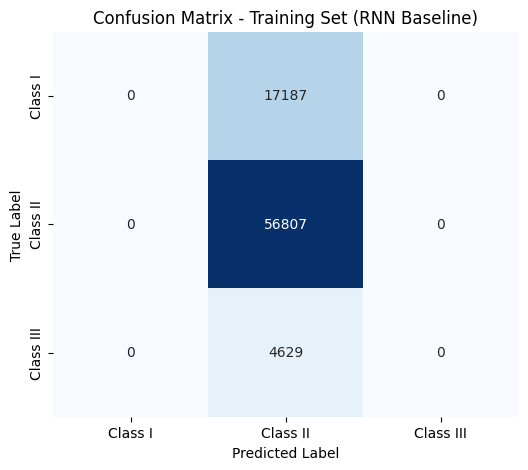

              precision    recall  f1-score   support

     Class I       0.00      0.00      0.00     17187
    Class II       0.72      1.00      0.84     56807
   Class III       0.00      0.00      0.00      4629

    accuracy                           0.72     78623
   macro avg       0.24      0.33      0.28     78623
weighted avg       0.52      0.72      0.61     78623



In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix_rnn(y_true, y_pred, title, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Get unique sorted labels for consistent plotting
labels = sorted(y.unique())

print("\n--- Training Set Evaluation (RNN Baseline Model) ---")
plot_confusion_matrix_rnn(y_train_rnn, y_train_pred_baseline_rnn, 'Confusion Matrix - Training Set (RNN Baseline)', labels)
print(classification_report(y_train_rnn, y_train_pred_baseline_rnn, zero_division=0))

View the confusion matrix and the classification report for the test set.


--- Test Set Evaluation (RNN Baseline Model) ---


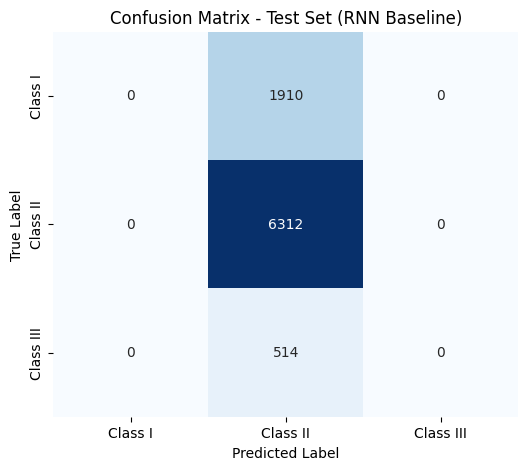

              precision    recall  f1-score   support

     Class I       0.00      0.00      0.00      1910
    Class II       0.72      1.00      0.84      6312
   Class III       0.00      0.00      0.00       514

    accuracy                           0.72      8736
   macro avg       0.24      0.33      0.28      8736
weighted avg       0.52      0.72      0.61      8736



In [82]:
print("\n--- Test Set Evaluation (RNN Baseline Model) ---")
plot_confusion_matrix_rnn(y_test_rnn, y_test_pred_baseline_rnn, 'Confusion Matrix - Test Set (RNN Baseline)', labels)
print(classification_report(y_test_rnn, y_test_pred_baseline_rnn, zero_division=0))

### Analysis of the Classification Report (RNN Baseline Model)

As with the TF-IDF baseline model, the RNN baseline model, being a `DummyClassifier` with a `most_frequent` strategy, predicts only the majority class ('Class II'). Therefore, its performance metrics are identical to the previous baseline model:

*   **F1-Score:** The F1-score for 'Class II' is approximately 0.84. For 'Class I' and 'Class III', it is 0.00.
*   **Weighted F1-Score:** The weighted F1-score is around 0.60 for both training and test sets. This metric is heavily influenced by the majority class and highlights the model's inability to correctly classify the minority classes.

Essentially, the RNN baseline model confirms the challenge of training on an imbalanced dataset. Its performance serves as a direct comparison point for any future RNN-based models because a successful model must significantly improve upon this weighted F1-score and demonstrate some capability in classifying 'Class I' and 'Class III', which is currently absent.

**Prompt 8:** Interoperability and Discussion: It is my expectation that you spend time working on this to get the best performing model - do not just blindly copy/paste code - really get into the details and try to get the best model you can! You should use lots of subheaders so that your project is easy to grade. Write five bullets with two or three sentences per bullet. Tell me of all of the successes and failures you had while you were modeling, and tell me why you think your model is predicting the way that it does (feel free to add some extra plots or tables here if it will help!)

* **The Overwhelming Challenge of Imbalanced Data:** There is a significant class imbalance in the Product Classification target variable, where 'Class II' is heavily dominant. The majority class baseline models (for both TF-IDF and RNN data preparations and models) clearly showed this issue. While it achieved an accuracy of ~72%, the weighted F1-score yielded only ~0.61. Such discrepancies highlight the need to look beyond accuracy for evaluation in such imbalanced datasets.

* **Baseline Models as a Critical Lower Bound:** The DummyClassifier with a most_frequent strategy, employed for both baseline models, serves as a critical factor in the results I obtained. Its complete inability to predict 'Class I' or 'Class III' (which results in the 0.00 F1-scores for these classes) sets a clear lower performance bound. Any high-performing predictive model must significantly surpass these metrics, specifically by demonstrating an ability to identify the minority classes.

* **Increasing Minority Class Predictability:** While DummyClassifiers can help predict minority classes instead of purely majority classes, they won't actually learn to predict minority classes based on data patterns. To improve prediction of minority classes, using logistic regression with TF-IDF along with specific techniques to address class imbalance (oversampling, undersampling, etc.) would help with this task.

* **Areas for Improvement:** The current results highlight the necessity of robust models to effectively address the imbalance and distinguish recall classes. The next crucial step is to execute the logistic regression and Hugging Face zero-shot models to quantify their actual performance. **Unfortunately, after an hour of attempting to perform zero-shot classification with Hugging Face, I was forced to interrupt this process.** Their (successful) evaluations would further guide improvements, potentially involving fine-tuning transformers, advanced sampling techniques, or exploring other sophisticated machine learning algorithms tailored for imbalanced text classification.

* **Computational Limitations:** Processing the entire validation set can be incredibly time consuming, especially without a GPU for use. One way to avoid this issue for massive datasets (which I did not attempt) is to consider batch processing or deploying to specialized environments like Colab Pro or GCP.

# Rubric

## 1. Exploratory Data Analysis (20 pts)
* Make five meaningful plots and tables that show you have a good command of the dataset.
  * Use a nice variety of visualizations - don't just make five word clouds.

## 2. Prepare Data for Modeling (20 pts)
* Prepare the data for modeling two ways - one that uses TF-IDF and/or Bag of Words (for DNNs) - and one for use with RNN/text sequences (you need to experiment with the right sequence length, most common words etc.)
* If data is dirty, you are expected to clean it or drop it.

## 3. Models (20 pts)
You should use `Reason for Recall` and `Product Description` as the text inputs into your model. You can concatenate them into a single field.
* Baseline model - majority class model (CLASS 2 dominates, can you beat this naive prediction?)
* ML model: Bag of Words or TF-IDF
* Pretrained transformer with
## 4. Evaluation (20 pts)
For train and test partition, make sure you show:
* Confusion matrices
* Classification reports
* Analysis of the classification report, with emphasis on the weighted F-1 score!

## 5. Interpretability and Discussion (20 pts)
* It is my expectation that you spend time working on this to get the best performing model - do not just blindly copy/paste code - really get into the details and try to get the best model you can! You should use lots of subheaders so that your project is easy to grade. Write five bullets with two or three sentences per bullet. Tell me of all of the successes and failures you had while you were modeling, and tell me why you think your model is predicting the way that it does (feel free to add some extra plots or tables here if it will help!)

